# Xây dựng mô hình K_Means

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist


Khởi tạo tâm cụm

In [ ]:
def kmeans_init_centers(X, k):
    centers = []
    # Random tâm đầu tiên
    np.random.seed(42)
    idx = np.random.randint(X.shape[0])
    centers.append(X[idx])

    for _ in range(1, k):
        # Tính khoảng cách từ mọi điểm đến các tâm ĐÃ CÓ
        dists = cdist(X, np.array(centers))

        # Lấy khoảng cách ngắn nhất từ mỗi điểm đến TÂM GẦN NHẤT của nó
        min_dists = np.min(dists, axis=1)

        # Chọn điểm có khoảng cách (đến tâm gần nhất) là xa nhất
        next_center = X[np.argmax(min_dists)]
        centers.append(next_center)

    return np.array(centers)

Tính khoảng cách xn đến tâm cụm và đưa ra cụm có khoảng cách nhỏ nhất

In [ ]:
def kmeans_assign_labels(X, centers):
    # calculate pairwise distances btw data and centers
    D = cdist(X, centers)
    # return index of the closest center
    return np.argmin(D, axis = 1)

Tính lại tâm cụm mới

In [ ]:
def kmeans_update_centers(X, labels, K):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
    # collect all points assigned to the k-th cluster
        Xk = X[labels == k, :]
        # take average
        centers[k,:] = np.mean(Xk, axis = 0)
    return centers

So sánh tâm cụm mới với tâm cụm cũ

In [ ]:
def has_converged(centers, new_centers, tol=1e-4):
    return np.linalg.norm(centers - new_centers) < tol


In [ ]:
def kmeans(X, K):
    centers = [kmeans_init_centers(X, K)]
    labels = []
    it = 0
    while True:
        labels.append(kmeans_assign_labels(X, centers[-1]))
        new_centers = kmeans_update_centers(X, labels[-1], K)
        if has_converged(centers[-1], new_centers):
            break
        centers.append(new_centers)
        it += 1
    return (centers, labels, it)

In [ ]:
def kmeans_predict(X, centers):
    return kmeans_assign_labels(X, centers)

In [ ]:
def kmeans_display(X, centers, labels):
    K = centers.shape[0]
    plt.figure(figsize=(8,6))
    for k in range(K):
        Xk = X[labels == k, :]
        plt.scatter(Xk[:,0], Xk[:,1], s=30)
    plt.scatter(centers[:,0], centers[:,1], s=200, marker='*', c='black')
    plt.title('K-means clustering')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Đọc dữ liệu

In [ ]:
import pandas as pd
df =  pd.read_excel("https://docs.google.com/spreadsheets/d/1S6LDJZWdgnj44FAuzrHlPmSlpinH-Unm/export?format=xlsx")
X = df.drop(columns=["Class"]).values


# Chọn K

In [ ]:
pip install kneed


In [ ]:
def calculate_metrics(X, k_range, n_init= 50):
    distortions = []
    silhouette_avg = []

    for k in k_range:
        best_dist = np.inf
        best_labels = None

        for _ in range(n_init):
            centers_hist, labels_hist, it = kmeans(X, k)
            centers = centers_hist[-1]
            labels = labels_hist[-1]

            dist = 0
            for i in range(k):
                Xk = X[labels == i]
                if len(Xk) > 0:
                    dist += np.sum((Xk - centers[i])**2)

            if dist < best_dist:
                best_dist = dist
                best_labels = labels

        distortions.append(best_dist)

        if len(np.unique(best_labels)) > 1:
            silhouette_avg.append(silhouette_score(X, best_labels))
        else:
            silhouette_avg.append(np.nan)
    return distortions, silhouette_avg


Thuật toán tự động xác định số cụm tối ưu là: K = 4


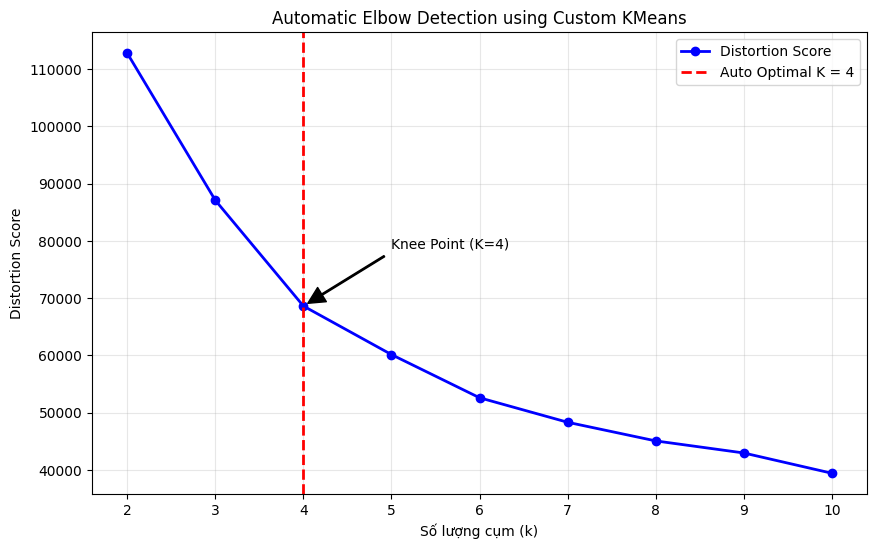

In [ ]:
from kneed import KneeLocator

k_range = range(2, 11)
distortions, _ = calculate_metrics(X, k_range)

kn = KneeLocator(k_range, distortions, S=1.0, curve='convex', direction='decreasing')
optimal_k = kn.knee

print(f"Thuật toán tự động xác định số cụm tối ưu là: K = {optimal_k}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, distortions, 'bo-', linewidth=2, label='Distortion Score')

if optimal_k is not None:
    plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
                label=f'Auto Optimal K = {optimal_k}')

    plt.annotate(f'Knee Point (K={optimal_k})',
                 xy=(optimal_k, distortions[optimal_k-2]),
                 xytext=(optimal_k+1, distortions[optimal_k-2] + 10000),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.xlabel('Số lượng cụm (k)')
plt.ylabel('Distortion Score')
plt.title('Automatic Elbow Detection using Custom KMeans')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
(centers_hist, labels_hist, it) = kmeans(X, optimal_k)
final_centers = centers_hist[-1]
final_labels = labels_hist[-1]

from sklearn.metrics import silhouette_samples, silhouette_score
full_silhouette_avg = silhouette_score(X, final_labels)
sample_silhouette_values = silhouette_samples(X, final_labels)

print(f"Silhouette Score trung bình của toàn bộ mô hình: {full_silhouette_avg:.4f}")

for i in range(optimal_k):
    cluster_score = sample_silhouette_values[final_labels == i].mean()
    cluster_size = len(X[final_labels == i])
    print(f"Cụm {i}: Số lượng mẫu = {cluster_size}, Silhouette trung bình = {cluster_score:.4f}")

Silhouette Score trung bình của toàn bộ mô hình: 0.3379
Cụm 0: Số lượng mẫu = 2304, Silhouette trung bình = 0.3131
Cụm 1: Số lượng mẫu = 2231, Silhouette trung bình = 0.4953
Cụm 2: Số lượng mẫu = 3202, Silhouette trung bình = 0.2863
Cụm 3: Số lượng mẫu = 5806, Silhouette trung bình = 0.3156


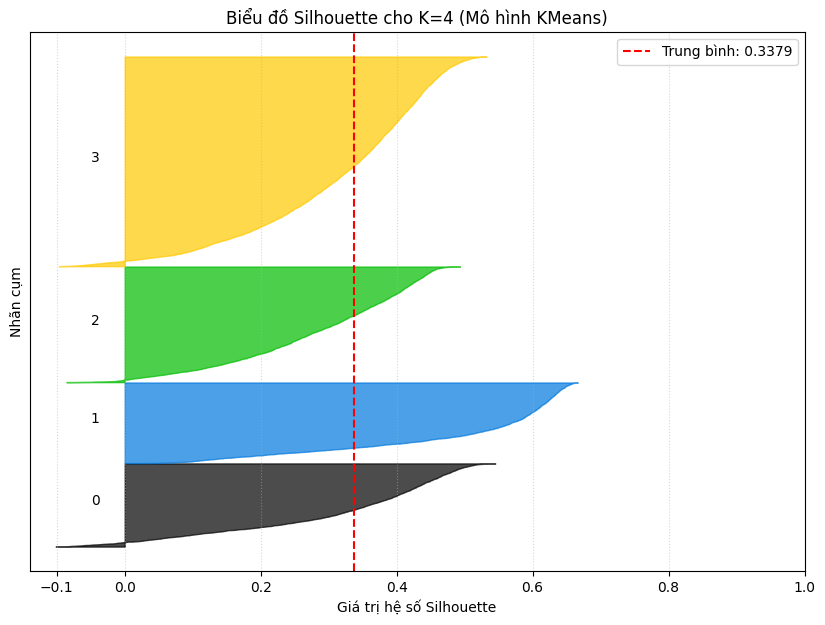

In [ ]:
import matplotlib.cm as cm

def plot_custom_silhouette_visualizer(X, labels, optimal_k):
    silhouette_avg = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)

    fig, ax1 = plt.subplots(figsize=(10, 7))
    y_lower = 10

    for i in range(optimal_k):
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / optimal_k)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10

    ax1.set_title(f"Biểu đồ Silhouette cho K={optimal_k} (Mô hình KMeans)")
    ax1.set_xlabel("Giá trị hệ số Silhouette")
    ax1.set_ylabel("Nhãn cụm")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Trung bình: {silhouette_avg:.4f}")

    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax1.legend(loc="upper right")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

plot_custom_silhouette_visualizer(X, final_labels, optimal_k)

# Trực quan hóa số cụm

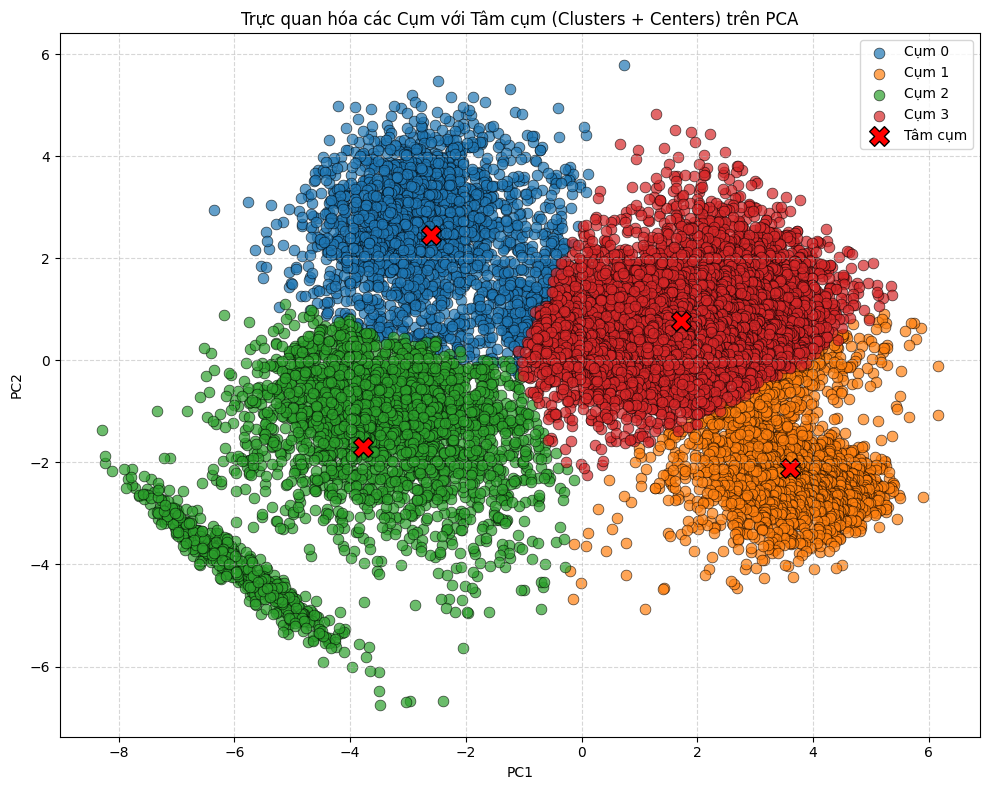

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA

def plot_pca_clusters_with_centers(X, labels, kmeans_centers=None):
    # PCA về 2 chiều
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 8))

    unique_clusters = np.unique(labels)
    colors = sns.color_palette("tab10", len(unique_clusters))  # màu cho mỗi cụm

    # Vẽ các điểm dữ liệu
    for i, cluster in enumerate(unique_clusters):
        mask = labels == cluster
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            c=[colors[i]],
            label=f'Cụm {cluster}',
            edgecolors='black',
            alpha=0.7,
            s=60,
            linewidths=0.5
        )

    # Vẽ tâm cụm nếu có
    if kmeans_centers is not None:
        centers_pca = pca.transform(kmeans_centers)  # chiếu tâm cụm vào PCA
        plt.scatter(
            centers_pca[:, 0],
            centers_pca[:, 1],
            c='red',
            marker='X',
            s=200,
            label='Tâm cụm',
            edgecolors='black'
        )

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Trực quan hóa các Cụm với Tâm cụm (Clusters + Centers) trên PCA')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


plot_pca_clusters_with_centers(X, final_labels, final_centers)


# Các chỉ số đánh giá mối quan hệ giữa các mẫu dữ liệu trong cụm

In [ ]:
from sklearn import metrics

db_score = metrics.davies_bouldin_score(X, final_labels)
ch_score = metrics.calinski_harabasz_score(X, final_labels)

print(f"BẢNG CHỈ SỐ ĐỊNH LƯỢNG :")
print(f"- Silhouette Score: {full_silhouette_avg:.4f}")
print(f"- Davies-Bouldin Index: {db_score:.4f}")
print(f"- Calinski-Harabasz Score: {ch_score:.2f}")

BẢNG CHỈ SỐ ĐỊNH LƯỢNG :
- Silhouette Score: 0.3379
- Davies-Bouldin Index: 1.0655
- Calinski-Harabasz Score: 9508.20


# Trực quan hóa số cụm và nhãn thực tế


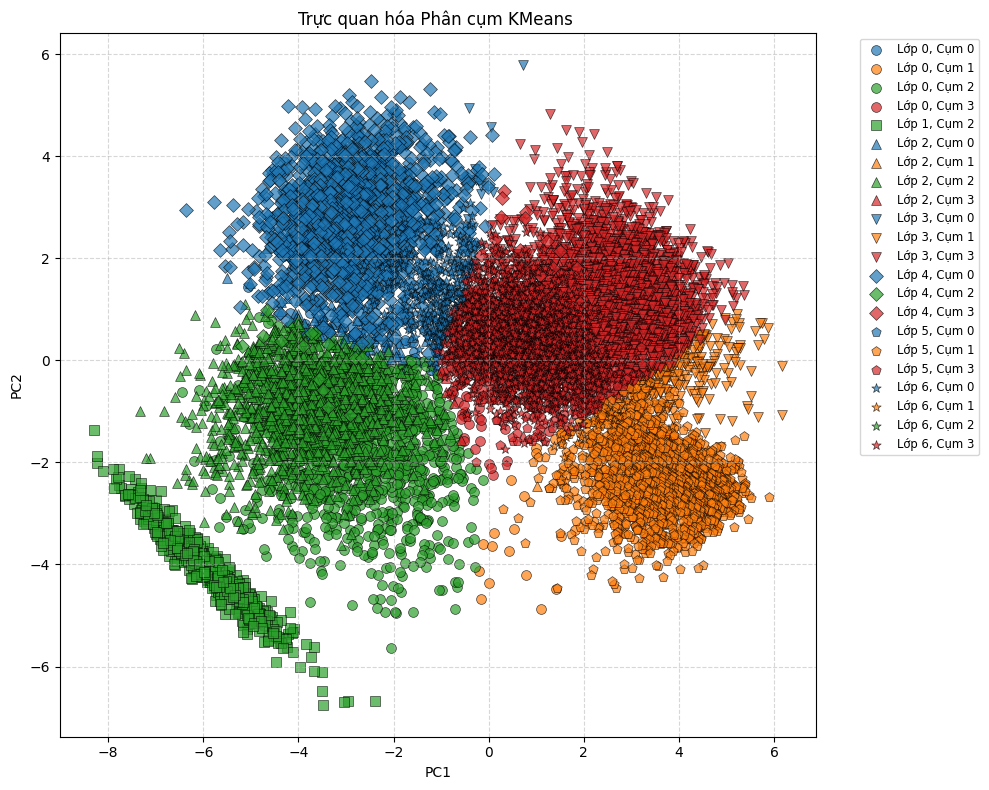

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def plot_pca_clusters(X, labels, actual_classes):
    plt.figure(figsize=(10, 8))
    unique_classes = np.unique(actual_classes)
    markers = ['o', 's', '^', 'v', 'D', 'p', '*']

    colors = sns.color_palette("tab10", len(np.unique(labels)))

    for i, cls in enumerate(unique_classes):
        for j, cluster in enumerate(np.unique(labels)):
            mask = (actual_classes == cls) & (labels == cluster)

            if np.any(mask):
                plt.scatter(
                    X[mask, 0], # PC1
                    X[mask, 1], # PC2
                    c=[colors[j]],
                    marker=markers[i],
                    label=f'Lớp {cls}, Cụm {cluster}',
                    edgecolors='black',
                    alpha=0.7,
                    s=50,
                    linewidths=0.5
                )

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Trực quan hóa Phân cụm KMeans ')

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=1)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Thực thi
plot_pca_clusters(X, final_labels, df['Class'].values)

# Các chỉ số đánh giá cụm với nhãn thực tế

In [ ]:
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, normalized_mutual_info_score

y_true = df['Class'].values
y_pred = final_labels

ari = adjusted_rand_score(y_true, y_pred)
fmi = fowlkes_mallows_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)

print("--- CÁC CHỈ SỐ SO SÁNH CỤM VS NHÃN THỰC TẾ ---")
print(f"1. Adjusted Rand Index (ARI): {ari:.4f}")
print(f"2. Fowlkes-Mallows Index (FMI): {fmi:.4f}")
print(f"3. Normalized Mutual Information (NMI): {nmi:.4f}")

--- CÁC CHỈ SỐ SO SÁNH CỤM VS NHÃN THỰC TẾ ---
1. Adjusted Rand Index (ARI): 0.5238
2. Fowlkes-Mallows Index (FMI): 0.6504
3. Normalized Mutual Information (NMI): 0.6439


# Số lượng và tỷ lệ phần trăm các nhãn thật trong mỗi cụm

In [ ]:
import pandas as pd

comparison_table = pd.crosstab(index=df['Class'],
                               columns=final_labels,
                               rownames=['Nhãn thực tế (Class)'],
                               colnames=['Cụm (Cluster)'])

print("Số lượng nhãn ban đầu trong mỗi cụm:")
print(comparison_table)

comparison_percentage = pd.crosstab(index=df['Class'],
                                    columns=final_labels,
                                    normalize='columns') * 100
print("\nTỷ lệ (%) các nhãn trong mỗi cụm:")
print(comparison_percentage.round(2))

Số lượng nhãn ban đầu trong mỗi cụm:
Cụm (Cluster)            0     1     2     3
Nhãn thực tế (Class)                        
0                       78    19  1151    74
1                        0     0   522     0
2                      107     2  1512     9
3                       14   276     0  3256
4                     1819     0    14    27
5                        1  1906     0   120
6                      285    28     3  2320

Tỷ lệ (%) các nhãn trong mỗi cụm:
col_0      0      1      2      3
Class                            
0       3.39   0.85  35.95   1.27
1       0.00   0.00  16.30   0.00
2       4.64   0.09  47.22   0.16
3       0.61  12.37   0.00  56.08
4      78.95   0.00   0.44   0.47
5       0.04  85.43   0.00   2.07
6      12.37   1.26   0.09  39.96
